# $R=\sigma_L/\sigma_T$ analysis

This notebook reads the bootstrap amplitude files for the $\rho^0$, $\omega$, and
$\phi$ channels, computes $R=H^4(00)/H^0(00)$, audits every input file, and
produces a publication-quality comparison with available published estimates.

The HERMES $\phi$ point uses the full-RICH sample averages
$\langle Q^2\rangle=1.95\,\mathrm{GeV}^2$ and
$\langle W^2\rangle=21.89\,\mathrm{GeV}^2$.  No external published $R$ value is
assumed for that point; the minimiser result is plotted without a fabricated
difference value.


In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import display
import ROOT

USE_TEX = False
mpl.rcParams["text.usetex"] = USE_TEX
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.4,
    "savefig.dpi": 300,
})

COLORS = {"minimiser": "#0072B2", "published": "#D55E00", "difference": "#222222"}


def apply_poster_axis_style(ax):
    ax.minorticks_on()
    ax.tick_params(which="major", direction="in", top=True, right=True, width=1.3, length=7, pad=6)
    ax.tick_params(which="minor", direction="in", top=True, right=True, width=1.0, length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)


In [2]:
# Paths and analysis configuration.
OUTPUT_DIR = Path(
    "~/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/OutputFiles"
).expanduser()
FIGURE_DIR = Path("outputs/R_analysis_bootstrap")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
BOOTSTRAP_TREE = "PartialWaves"
BOOTSTRAP_FILE_TEMPLATE = "{filename}_bootstrap_{bin_index}.root"
R_EXPRESSION = "H_4_0_0/H_0_0_0"
R_REQUIRED_BRANCHES = ("H_4_0_0", "H_0_0_0")

Q2_HERMES_RHO = np.array([0.82, 1.19, 1.66, 3.06])
Q2_COMPASS_RHO = np.array([1.14, 1.60, 2.80, 6.02])
Q2_HERMES_OMEGA = np.array([1.28, 2.00, 4.00])
Q2_COMPASS_OMEGA = np.array([1.16, 1.64, 3.58])
Q2_HERMES_PHI = np.array([1.2,1.4,4.5])

PUBLISHED_HERMES_RHO = np.array([
    [0.649, 0.188], [0.671, 0.065], [0.794, 0.083], [1.068, 0.087],
])
PUBLISHED_COMPASS_RHO = np.array([
    [0.724, 0.078], [0.930, 0.081], [1.227, 0.122], [1.200, 0.729],
])
PUBLISHED_HERMES_OMEGA = np.array([
    [0.226, 0.066], [0.237, 0.091], [0.283, 0.091],
])
PUBLISHED_COMPASS_OMEGA = np.array([
    [0.475, 0.085], [0.495, 0.124], [0.739, 0.197],
])
PUBLISHED_HERMES_PHI= np.array([
    [0.426, 0.038], [0.621, 0.054], [0.844, np.sqrt(0.071**2 + 0.004**2)],
])

CHANNELS = [
    dict(key="e_rho", filename="ElRho", title=r"$e^-\rho^0$", q2=Q2_HERMES_RHO,
         published=PUBLISHED_HERMES_RHO, published_label="Published HERMES", mass=0.775),
    dict(key="mu_rho", filename="MuRho", title=r"$\mu^-\rho^0$", q2=Q2_COMPASS_RHO,
         published=PUBLISHED_COMPASS_RHO, published_label="Published COMPASS", mass=0.775),
    dict(key="e_omega", filename="ElOmega", title=r"$e^-\omega$", q2=Q2_HERMES_OMEGA,
         published=PUBLISHED_HERMES_OMEGA, published_label="Published HERMES", mass=0.782),
    dict(key="mu_omega", filename="MuOmega", title=r"$\mu^-\omega$", q2=Q2_COMPASS_OMEGA,
         published=PUBLISHED_COMPASS_OMEGA, published_label="Published COMPASS", mass=0.782),
    # dict(key="e_phi", filename="ElPhi", title=r"$e^-\phi$", q2=Q2_HERMES_PHI,
    #      published=PUBLISHED_HERMES_PHI, published_label="Thesis", mass=1.019),
]


def vmd_model(q2, c0, c1, mass):
    return c0 * (q2 / mass) ** c1


def channel_file(channel, bin_index, template=BOOTSTRAP_FILE_TEMPLATE):
    return (OUTPUT_DIR / template.format(
        filename=channel["filename"], bin_index=bin_index,
    )).resolve()


In [3]:
# -------------------------------------------------------------------------
# ROOT file auditing and exact reading helpers
# -------------------------------------------------------------------------
def _root_column_names(rdf):
    return {str(name) for name in rdf.GetColumnNames()}

def inspect_root_file(path, tree_name):
    path = Path(path).expanduser().resolve()
    info = {
        "path": str(path),
        "basename": path.name,
        "exists": path.exists(),
        "size_mb": np.nan,
        "modified": "",
        "tree": tree_name,
        "tree_found": False,
        "entries": np.nan,
        "uuid": "",
    }

    if not path.exists():
        return info

    stat = path.stat()
    info["size_mb"] = stat.st_size / 1e6
    info["modified"] = datetime.fromtimestamp(stat.st_mtime).strftime("%Y-%m-%d %H:%M:%S")

    f = ROOT.TFile.Open(str(path), "READ")
    if not f or f.IsZombie():
        return info

    try:
        tree = f.Get(tree_name)
        info["tree_found"] = bool(tree)
        if tree:
            info["entries"] = int(tree.GetEntries())
        try:
            info["uuid"] = f.GetUUID().AsString()
        except Exception:
            info["uuid"] = ""
    finally:
        f.Close()

    return info

def audit_expected_files(channels=CHANNELS, tree_name=BOOTSTRAP_TREE):
    rows = []
    for channel in channels:
        for bin_index, q2 in enumerate(channel["q2"]):
            info = inspect_root_file(channel_file(channel, bin_index), tree_name)
            info.update({
                "channel": channel["key"],
                "bin": bin_index,
                "Q2": q2,
            })
            rows.append(info)

    cols = ["channel", "bin", "Q2", "basename", "exists", "tree_found", "entries",
            "size_mb", "modified", "uuid", "path"]
    return pd.DataFrame(rows)[cols]

def find_same_named_files(search_root, channels=CHANNELS):
    # Optional sanity check for duplicate basenames under a directory.
    search_root = Path(search_root).expanduser()
    expected = {
        channel_file(channel, bin_index).name
        for channel in channels
        for bin_index, _ in enumerate(channel["q2"])
    }

    rows = []
    for path in search_root.rglob("*.root"):
        if path.name in expected:
            rows.append({
                "basename": path.name,
                "path": str(path.resolve()),
                "size_mb": path.stat().st_size / 1e6,
                "modified": datetime.fromtimestamp(path.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S"),
            })
    return pd.DataFrame(rows).sort_values(["basename", "path"])

def make_rdf(path, tree_name=BOOTSTRAP_TREE, required_columns=()):
    path = Path(path).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(f"Missing ROOT file: {path}")

    rdf = ROOT.RDataFrame(tree_name, str(path))
    columns = _root_column_names(rdf)
    missing = [name for name in required_columns if name not in columns]
    if missing:
        raise KeyError(f"{path.name} is missing columns {missing} in tree {tree_name}")

    return rdf

audit = audit_expected_files()
display(audit)

if not audit["exists"].all() or not audit["tree_found"].all():
    missing = audit.loc[~audit["exists"] | ~audit["tree_found"], ["channel", "bin", "path", "exists", "tree_found"]]
    display(missing)
    raise FileNotFoundError("Some expected ROOT files/trees were not found. See the displayed audit table.")


,channel,bin,Q2,basename,exists,tree_found,entries,size_mb,modified,uuid,path
0,e_rho,0,0.82,ElRho_bootstrap_0.root,True,True,1000,0.755197,2026-08-04 21:15:14,3411d6a6-9041-11f1-97c6-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
1,e_rho,1,1.19,ElRho_bootstrap_1.root,True,True,1000,0.752028,2026-08-04 21:58:43,46cae89a-9047-11f1-89a1-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
2,e_rho,2,1.66,ElRho_bootstrap_2.root,True,True,1000,0.752052,2026-08-04 22:43:10,7cd1fb76-904d-11f1-9213-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
3,e_rho,3,3.06,ElRho_bootstrap_3.root,True,True,1000,0.750487,2026-08-04 23:26:54,9904b044-9053-11f1-9068-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
4,mu_rho,0,1.14,MuRho_bootstrap_0.root,True,True,1000,0.748634,2026-08-04 21:37:20,4a4f01d4-9044-11f1-9105-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
5,mu_rho,1,1.60,MuRho_bootstrap_1.root,True,True,1000,0.748385,2026-08-04 22:21:47,801be984-904a-11f1-810b-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
6,mu_rho,2,2.80,MuRho_bootstrap_2.root,True,True,1000,0.748649,2026-08-04 23:04:12,6d27425a-9050-11f1-a4b5-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
7,mu_rho,3,6.02,MuRho_bootstrap_3.root,True,True,1000,0.753833,2026-08-04 23:48:49,a8c091da-9056-11f1-a91b-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
8,e_omega,0,1.28,ElOmega_bootstrap_0.root,True,True,1000,0.756503,2026-08-05 00:32:55,d1e2bc40-905c-11f1-801b-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...
9,e_omega,1,2.00,ElOmega_bootstrap_1.root,True,True,1000,0.756304,2026-08-05 01:17:31,0c7de964-9063-11f1-a3e4-1bd93289beef,/home/dleahy27/Desktop/PhD/Electroproduction/E...


In [4]:
# -------------------------------------------------------------------------
# Read R from the bootstrap files
# -------------------------------------------------------------------------
def read_R_for_file(path):
    rdf = make_rdf(path, BOOTSTRAP_TREE, required_columns=R_REQUIRED_BRANCHES)
    rdf = rdf.Define("R", R_EXPRESSION)
    mean = float(rdf.Mean("R").GetValue())
    std = float(rdf.StdDev("R").GetValue())
    n = int(rdf.Count().GetValue())
    return mean, std, n

def compute_R_results(channels=CHANNELS):
    rows = []
    for channel in channels:
        for bin_index, q2 in enumerate(channel["q2"]):
            path = channel_file(channel, bin_index)
            mean, std, n = read_R_for_file(path)
            rows.append({
                "channel": channel["key"],
                "title": channel["title"],
                "bin": bin_index,
                "Q2": q2,
                "R_mean": mean,
                "R_std": std,
                "entries": n,
                "file": str(path),
            })
    return pd.DataFrame(rows)

R_results = compute_R_results()
display(R_results[["channel", "bin", "Q2", "R_mean", "R_std", "entries", "file"]])


,channel,bin,Q2,R_mean,R_std,entries,file
0,e_rho,0,0.82,0.630594,0.164261,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
1,e_rho,1,1.19,0.758958,0.096700,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
2,e_rho,2,1.66,0.733353,0.111073,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
3,e_rho,3,3.06,1.050607,0.129982,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
4,mu_rho,0,1.14,0.716134,0.046619,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
5,mu_rho,1,1.60,1.006735,0.080755,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
6,mu_rho,2,2.80,1.028736,0.063752,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
7,mu_rho,3,6.02,1.149426,0.264398,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
8,e_omega,0,1.28,0.720496,0.337100,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...
9,e_omega,1,2.00,0.602601,0.326424,1000,/home/dleahy27/Desktop/PhD/Electroproduction/E...


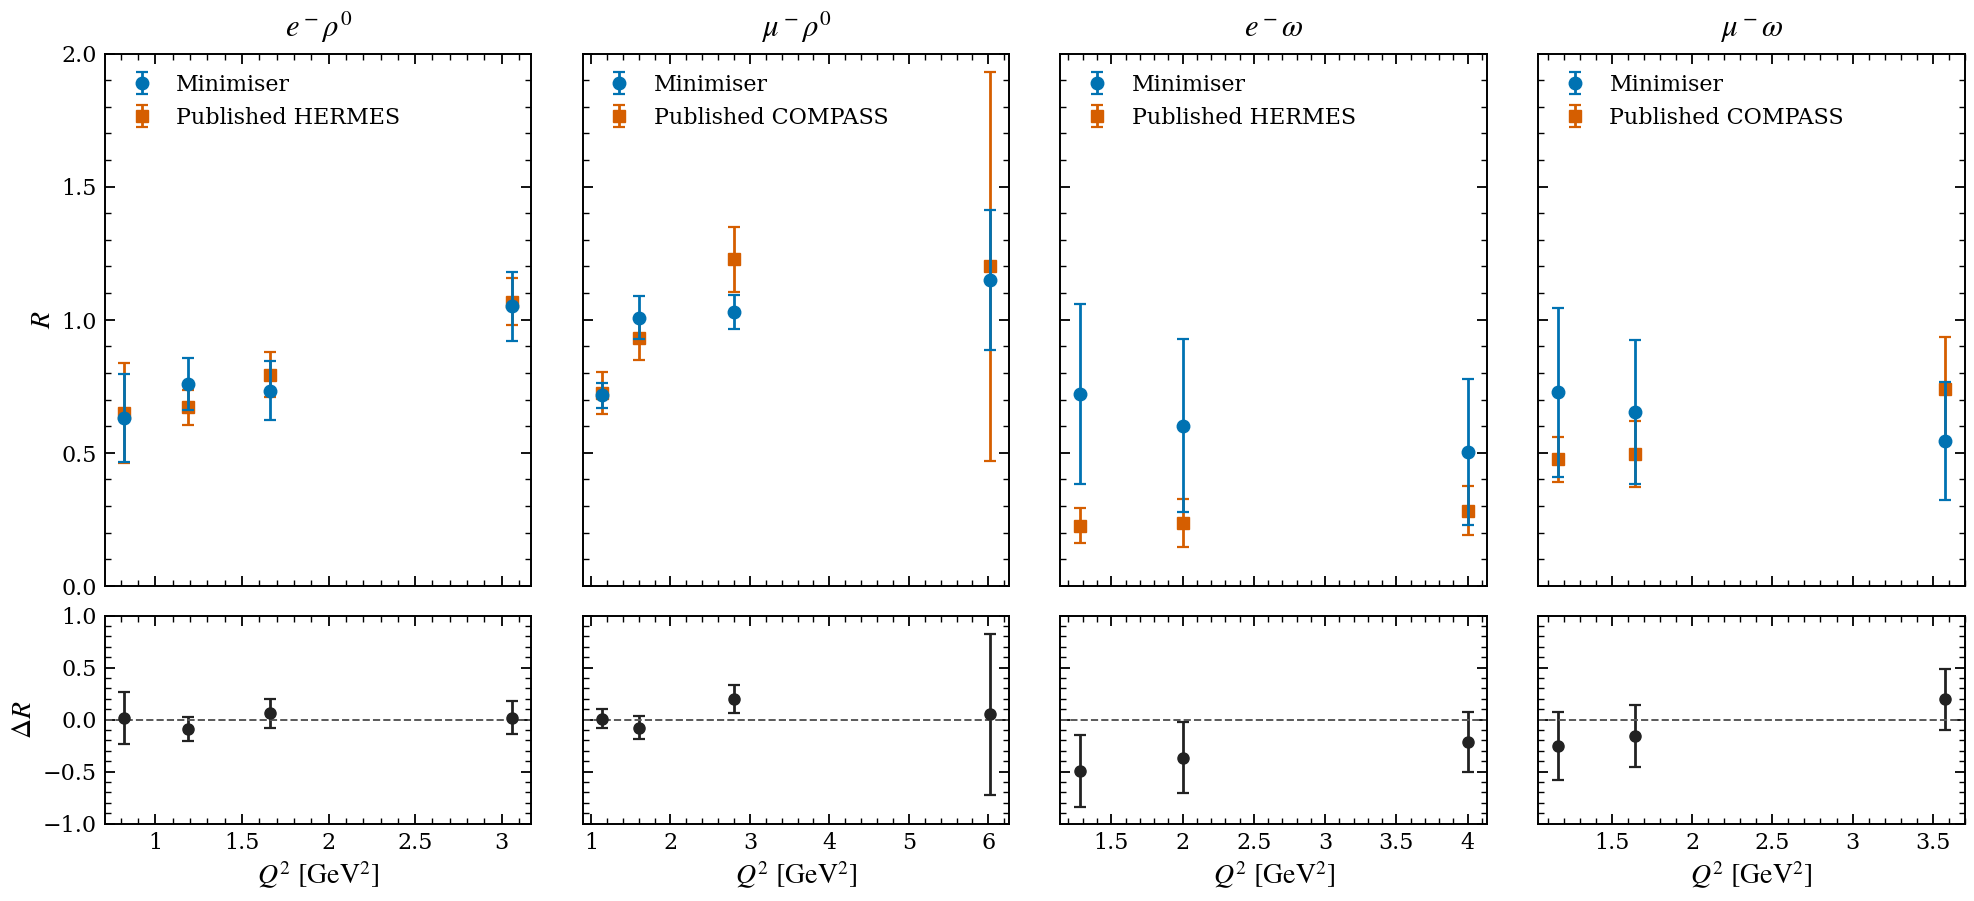

Saved /home/dleahy27/Desktop/PhD/Electroproduction/Electroproduction-Moments-Inverter/AnalysisScripts/RScaling_rho_omega_phi.png


In [5]:
# Plot minimiser R and the available published estimates.
def fit_vmd_curve(channel, q2, y):
    if len(q2) < 2:
        raise ValueError("At least two Q2 points are required for a VMD curve fit")
    model = lambda x, c0, c1: vmd_model(x, c0, c1, channel["mass"])
    return curve_fit(model, q2, y, p0=[1.0, 1.0], maxfev=10000)


def plot_R_scaling(results, channels=CHANNELS, show_fit_lines=False,
                   output_name="RScaling_rho_omega_phi.png"):
    n_channels = len(channels)
    fig = plt.figure(figsize=(24, 10))
    gs = fig.add_gridspec(2, n_channels, height_ratios=[3.2, 1.25], hspace=0.08, wspace=0.12)
    top_axes = [fig.add_subplot(gs[0, i]) for i in range(n_channels)]
    diff_axes = [fig.add_subplot(gs[1, i]) for i in range(n_channels)]

    for ax in top_axes[1:]:
        ax.sharey(top_axes[0])
    for ax in diff_axes[1:]:
        ax.sharey(diff_axes[0])

    for idx, channel in enumerate(channels):
        ax, axd = top_axes[idx], diff_axes[idx]
        subset = results.loc[results["channel"] == channel["key"]].sort_values("bin")
        q2 = subset["Q2"].to_numpy()
        mine = subset["R_mean"].to_numpy()
        mine_err = subset["R_std"].to_numpy()

        ax.errorbar(
            q2, mine, yerr=mine_err, fmt="o", markersize=9,
            elinewidth=2.0, capsize=4, capthick=1.6,
            color=COLORS["minimiser"], label="Minimiser", zorder=5,
        )

        published = channel.get("published")
        if published is not None:
            pub_y, pub_err = published[:, 0], published[:, 1]
            ax.errorbar(
                q2, pub_y, yerr=pub_err, fmt="s", markersize=8,
                elinewidth=2.0, capsize=4, capthick=1.6,
                color=COLORS["published"], label=channel["published_label"],
            )

            if show_fit_lines and len(q2) >= 2:
                q2_fit = np.linspace(max(0.5, 0.8 * q2.min()), 1.1 * q2.max(), 500)
                popt_mine, _ = fit_vmd_curve(channel, q2, mine)
                popt_pub, _ = fit_vmd_curve(channel, q2, pub_y)
                ax.plot(q2_fit, vmd_model(q2_fit, *popt_mine, channel["mass"]),
                        color=COLORS["minimiser"])
                ax.plot(q2_fit, vmd_model(q2_fit, *popt_pub, channel["mass"]),
                        "--", color=COLORS["published"])

            diff = pub_y - mine
            diff_err = np.sqrt(pub_err**2 + mine_err**2)
            axd.errorbar(
                q2, diff, yerr=diff_err, fmt="o", markersize=8,
                elinewidth=2.0, capsize=4, capthick=1.6,
                color=COLORS["difference"],
            )
        else:
            axd.text(
                0.5, 0.5, "No external comparison",
                ha="center", va="center", transform=axd.transAxes,
                fontsize=12, color="0.35",
            )

        axd.axhline(0, ls="--", color="0.35", linewidth=1.4)
        ax.set_title(channel["title"], pad=12)
        ax.tick_params(labelbottom=False)
        axd.set_xlabel(r"$Q^2\ [\mathrm{GeV}^2]$")
        ax.legend(loc="upper left", frameon=False, handlelength=1.5)

        if idx > 0:
            ax.tick_params(labelleft=False)
            axd.tick_params(labelleft=False)

    top_axes[0].set_ylabel(r"$R$")
    diff_axes[0].set_ylabel(r"$\Delta R$")
    top_axes[0].set_ylim(0, 2)
    top_axes[0].set_yticks([0, 0.5, 1, 1.5, 2])
    diff_axes[0].set_ylim(-1, 1)

    for ax in top_axes + diff_axes:
        ax.xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:g}"))
        apply_poster_axis_style(ax)

    out = FIGURE_DIR / output_name
    fig.savefig(out, transparent=True, bbox_inches="tight")
    plt.show()
    print(f"Saved {out}")


plot_R_scaling(R_results, show_fit_lines=False)
